In [2]:
from __future__ import annotations

from pathlib import Path

from qsim.pulse.visualize import (
    auto_fold_long_pulses,
    make_timing_theme,
    plot_pulses,
    pulse_ir_from_qasm,
    reorder_xy_z_channels,
)


def _write_case_inputs(case_dir: Path, qasm_text: str, backend_yaml_text: str) -> tuple[Path, Path]:
    qasm_path = case_dir / "input.qasm"
    backend_path = case_dir / "backend.yaml"
    qasm_path.write_text(qasm_text, encoding="utf-8")
    backend_path.write_text(backend_yaml_text, encoding="utf-8")
    return qasm_path, backend_path



def _backend_yaml() -> str:
    return """level: qubit
noise: deterministic
solver: se
analysis_pipeline: default
seed: 1234
"""

def generate_case(case_name: str, qasm_text: str, out_dir: Path) -> None:
    case_dir = out_dir / case_name
    case_dir.mkdir(parents=True, exist_ok=True)
    qasm_path, backend_path = _write_case_inputs(case_dir, qasm_text, _backend_yaml())

    pulse_ir = pulse_ir_from_qasm(
        qasm_path.read_text(encoding="utf-8"),
        backend_config=backend_path,
        hardware={
            "xy_freq_hz": 5.0e9,
            "ro_freq_hz": 8.0e9,
            "gate_duration": 20.0,
            "measure_duration": 2000.0,
        },
    )
    pulse_ir = reorder_xy_z_channels(pulse_ir)
    breaks = auto_fold_long_pulses(
        pulse_ir,
        channel_prefixes=("RO",),
        min_pulse_ns=1000.0,
        keep_head_ns=40.0,
        keep_tail_ns=40.0,
    )

    timing_theme = make_timing_theme(break_display_gap_ns=16.0)

    png_path = case_dir / "timing_python.png"
    dxf_path = case_dir / "timing_diagram.dxf"
    metadata_path = case_dir / "pulse_metadata.json"
    plot_pulses(
        pulse_ir,
        timing_layout=True,
        title=case_name,
        show_clock=True,
        breaks=breaks,
        carrier_plot_max_hz=0.5e9,
        dxf_path=dxf_path,
        png_path=png_path,
        theme=timing_theme,
        pulse_metadata_path=metadata_path,
        target_ticks=20,
    )

    print(f"[OK] {case_name}")
    print(f"  qasm:        {qasm_path}")
    print(f"  backend:     {backend_path}")
    print(f"  python plot: {png_path}")
    print(f"  dxf:         {dxf_path}")
    print(f"  pulses json: {metadata_path}")



[OK] surface_code_3
  qasm:        runs\surface code 3\surface_code_3\input.qasm
  backend:     runs\surface code 3\surface_code_3\backend.yaml
  python plot: runs\surface code 3\surface_code_3\timing_python.png
  dxf:         runs\surface code 3\surface_code_3\timing_diagram.dxf
  pulses json: runs\surface code 3\surface_code_3\pulse_metadata.json


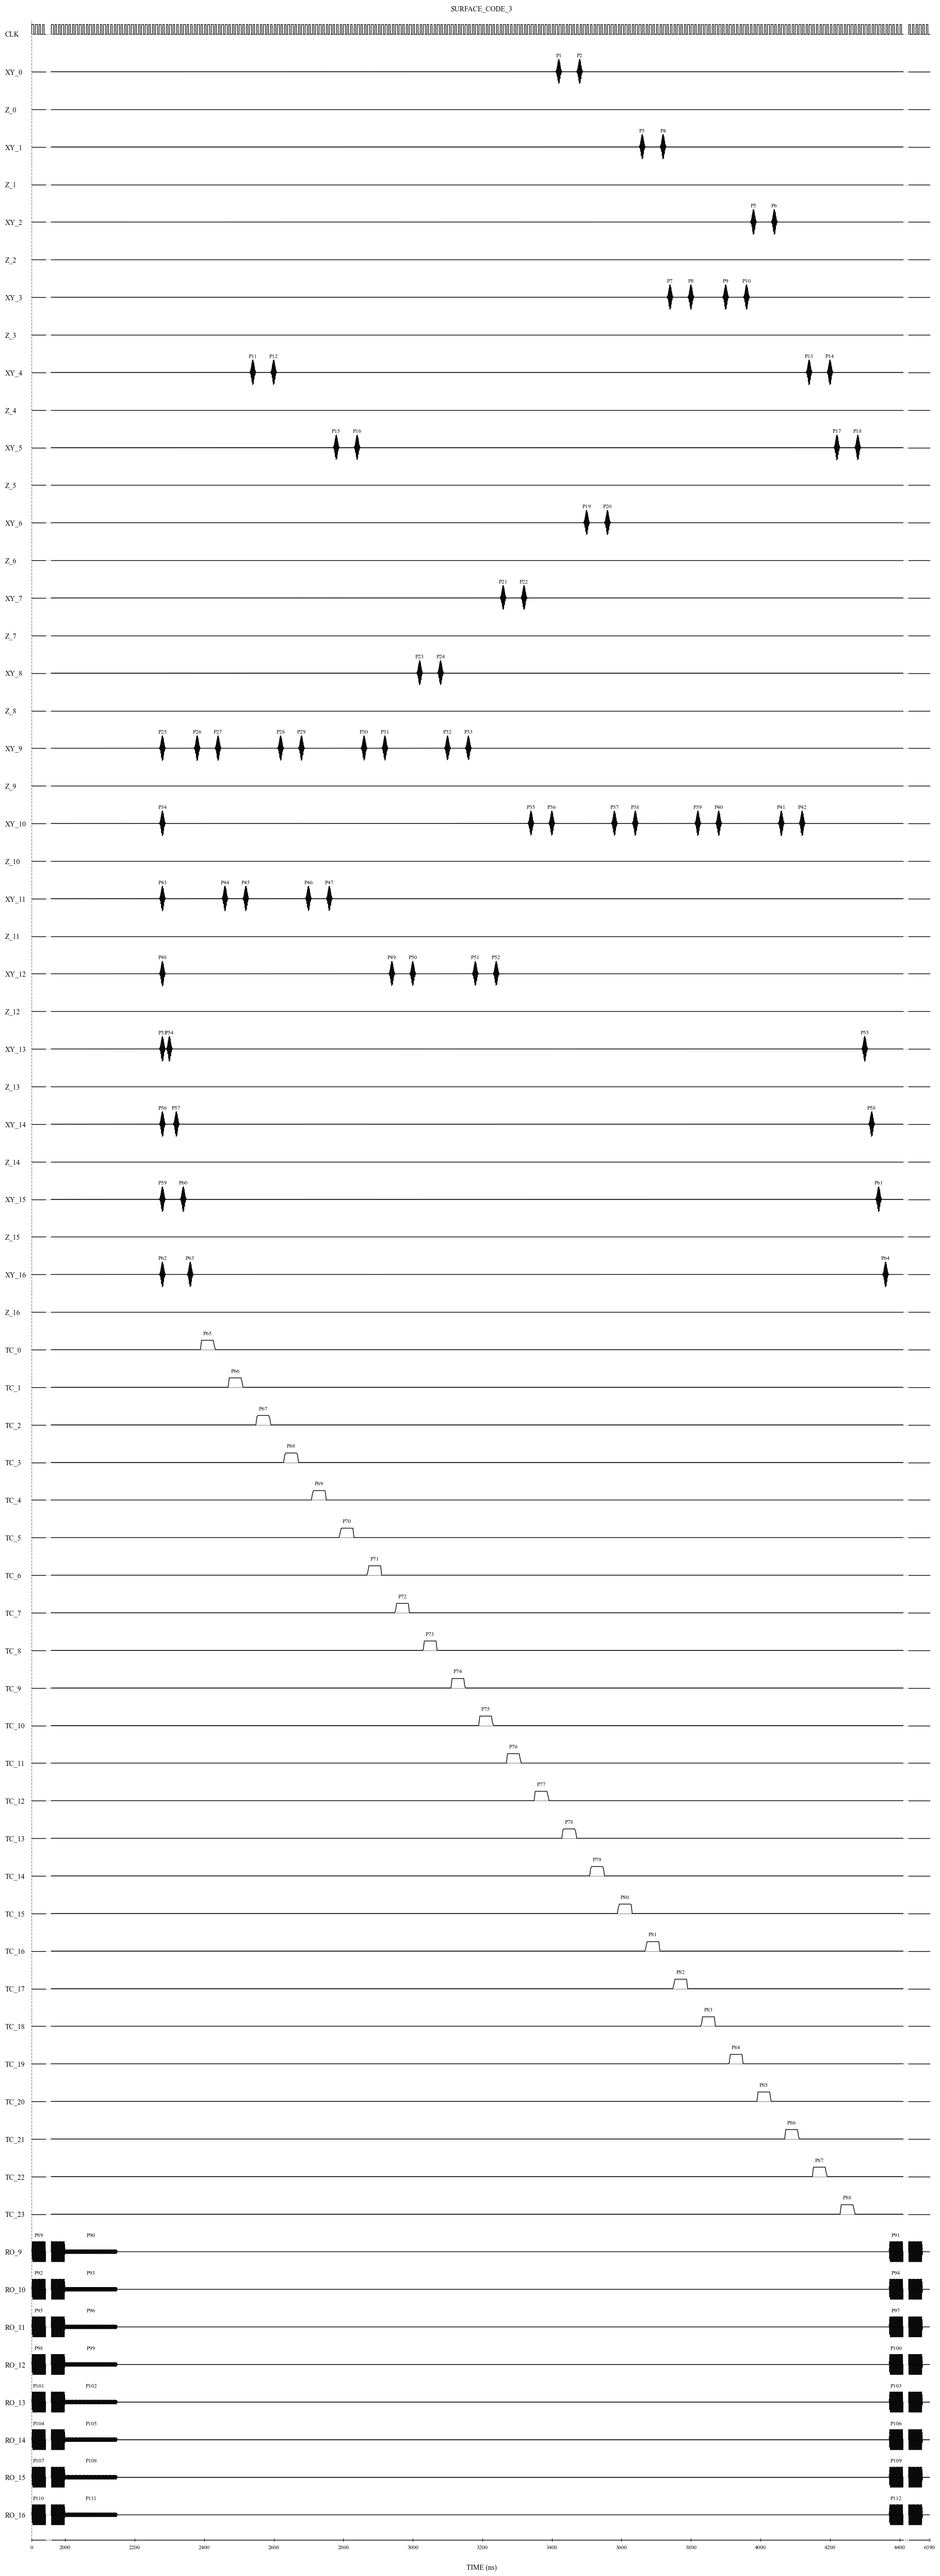

In [3]:
case_name = "surface_code_3"
f = open("surface_3.txt", "r")
qasm_text = f.read()
f.close()

out_dir = Path("runs") / "surface code 3"

generate_case(case_name, qasm_text, out_dir)


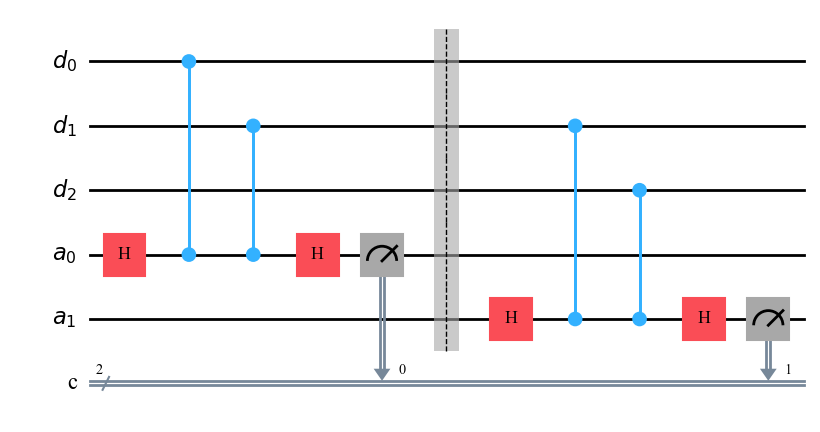

In [25]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import circuit_drawer

def circuit_H_CZ_CZ_H() -> QuantumCircuit:
    """
    Your circuit: H on ancilla, CNOT(d1->a), CNOT(d2->a), H on ancilla.
    Qubits: q0=d1, q1=d2, q2=ancilla
    """
    data = QuantumRegister(3, name="d")
    anc  = QuantumRegister(2, name="a")
    c    = ClassicalRegister(2, name="c")

    qc = QuantumCircuit(data, anc, c)

    # H - CX - CX - H on ancilla
    qc.h(anc[0])
    qc.cz(data[0], anc[0])
    qc.cz(data[1], anc[0])
    qc.h(anc[0])

    qc.measure(anc[0],c[0])

    qc.barrier()
    
    qc.h(anc[1])
    qc.cz(data[1], anc[1])
    qc.cz(data[2], anc[1])
    qc.h(anc[1])

    # measure ancilla (optional for drawing)
    qc.measure(anc[1],c[1])
    return qc

qc_bad = circuit_H_CZ_CZ_H()

qc_bad.draw(output="mpl")